# Section 2

#### Question 1
In this first step we load all the matrices and the embaddings that will be used in the next steps, and we invistigate their structure.

In [1]:
import numpy as np
import json
import os


# We define a helper function to extract and print some info about the data, and finally define the Matrices that will be used afterwards.
def inspect_data_file(file_path, name):
    try:
        # We load the file
        matrix = np.load(file_path)
        print(f"--- {name} ---")
        print(f"Shape (Dimensions): {matrix.shape}")
        # Print the table to see the kind of data they include 
        print(f"Data :\n{matrix}\n")
        return matrix
    except FileNotFoundError:
        print(f"Could not find {file_path}. Please check the filename or file path.\n")
        return None

In [2]:

# First, we load the Embedding Matrix (E)
E = inspect_data_file('E.npy', 'Embedding Matrix (E)')

# Then, we load the Self-Attention Weight Matrices
W_Q_self = inspect_data_file('W_Q_self.npy', 'W_Q (Self-Attention)')
W_K_self = inspect_data_file('W_K_self.npy', 'W_K (Self-Attention)')
W_V_self = inspect_data_file('W_V_self.npy', 'W_V (Self-Attention)')

# We load the Cross-Attention Weight Matrices
W_Q_cross = inspect_data_file('W_Q_cross.npy', 'W_Q (Cross-Attention)')
W_K_cross = inspect_data_file('W_K_cross.npy', 'W_K (Cross-Attention)')
W_V_cross = inspect_data_file('W_V_cross.npy', 'W_V (Cross-Attention)')

# Lastly, we load the Vocabulary JSON to see the words and their IDs,
try:
    with open('vocab.json', 'r', encoding='utf-8') as f:
        vocab = json.load(f)
        print(f"--- Vocabulary ---")
        print(f"Vocabulary size: {len(vocab)} words")
        # Print the dictionary
        print(f"Vaocabulary items: {list(vocab.items())}")
except FileNotFoundError:
    print("Could not find vocab.json")


--- Embedding Matrix (E) ---
Shape (Dimensions): (8, 8)
Data :
[[-0.08499407  0.03219409  0.17890428  1.5879339   0.03715928  0.14876938
   1.0728666   0.20812488]
 [ 1.3662732   1.5125351   0.05442212 -0.06738275  0.00196447 -0.10580851
   0.86519337  0.1219826 ]
 [-0.24001908 -0.15565798  1.4585176  -0.10050698  0.09691765  0.06467504
   1.0267265   0.1547032 ]
 [ 1.6176536   0.11499613  0.03800824  0.00351438  0.08768966  1.0978706
   0.03679502  0.01743195]
 [ 0.05349831  1.5907043   0.09889982 -0.08052988 -0.02796759  1.0748539
   0.01322922 -0.00196898]
 [ 0.09568585 -0.00851785  1.5633037  -0.11527568  0.17274047  0.9407415
  -0.03513554  0.24335372]
 [ 0.1438438   0.04894554 -0.03960076 -0.04578537  1.3411354   0.928501
  -0.27130342  0.03975172]
 [ 0.01558632 -0.10654304  0.00777481  1.3370427  -0.04269947  1.0402708
   0.09996877  0.03543867]]

--- W_Q (Self-Attention) ---
Shape (Dimensions): (8, 4)
Data :
[[ 0.93394685 -0.03934444  0.14014924 -0.15580803]
 [ 0.09668674  0.83

#### Answer to Question 1
Based on the previous printouts (from the .npy files), we can easily find the required dimensions for the model. The shape of the Embedding matrix ($E$) is (8, 8), which means the dimension of the embeddings is $8$ (the number of columns). The shapes of the weight matrices $W^Q$ and $W^K$ are (8, 4), which means the dimension of the queries and keys is $d_k = 4$. The shape of the weight matrix $W^V$ is (8, 6), so the dimension of the values is $d_u = 6$.

To find the sequence lengths, we can count the tokens in each sentence:

English tokens: ["Maria", "isn't", "here"] $\rightarrow$ Length: 3

Greek tokens: ["Δεν", "είναι", "εδώ", "η", "Μαρία"] $\rightarrow$ Length: 5

For the self-attention case (where we use only the English sentence), both the input sequence length ($T$) and the output sequence length ($T'$) are $3$. For the cross-attention case (corresponding to the translation from Greek to English), the input sequence is the Greek sentence, so $T = 5$, and the output sequence is the English sentence, so $T' = 3$.


#### Question 2

In this step we define the function that calculates the scalled dot product of the matrices $$

In [3]:
def scaled_dot_product_attention(Q, K, V):
    """
    The function computes the scaled dot-product attention mechanism.
    
    Args:
        Q: Query matrix 
        K: Key matrix 
        V: Value matrix 
        
    Returns:
        The A and Y matrices, where A is the attention weights matrix and Y is the output of the attention mechanism.
    """
    # Step 1: Calculate the dot product of Q and K^T
    scores = Q @ K.T

    # Step 2: Scale the scores by the square root of the dimension of the key (K) vectors
    d_k = K.shape[1]
    scaled_scores = scores / np.sqrt(d_k)

    # Step 3: Apply softmax to get the attention weights. We subtract the max row value for numerical stability.
    attention_weights = np.exp(scaled_scores - np.max(scaled_scores, axis=-1, keepdims=True))

    # We define the attention weights matrix A.
    A = attention_weights / np.sum(attention_weights, axis=-1, keepdims=True)

    # Step 4: Multiply the attention weights with the value matrix V
    Y = A @ V

    return Y , A

#### Question 3

In this step we calculate the matrices $Q$, $K$, and $V$, based on the given projection matrices $W_Q$, $W_K$, and $W_V$ amd the embeddings matrix $E$ and the vocabulary, and the matrices $A$ and $Y$ using the previous function.

In [4]:
# First we have to extract the Embeddings (X) for the two sentences ---
X_eng = E[[0, 1, 2]]         
X_el = E[[3, 4, 5, 6, 7]]

# --- Based on the extracted embeddings, we calculate Q, K, V ---

# Self-Attention (English sentence only)
Q_self = X_eng @ W_Q_self
K_self = X_eng @ W_K_self
V_self = X_eng @ W_V_self

# Cross-Attention (Greek to English)
# Queries come from the target (English), Keys/Values from the source (Greek)
Q_cross = X_eng @ W_Q_cross
K_cross = X_el @ W_K_cross
V_cross = X_el @ W_V_cross


print("=== Shapes of Language Embeddings ===")
print(f"Shape of X_eng: {X_eng.shape}")
print(f"Shape of X_el: {X_el.shape}\n")

print("=== Shapes of Projection Matrices ===")
print(f"Shape of W_Q_self: {W_Q_self.shape}")
print(f"Shape of W_K_self: {W_K_self.shape}")
print(f"Shape of W_V_self: {W_V_self.shape}")
print(f"Shape of W_Q_cross: {W_Q_cross.shape}")
print(f"Shape of W_K_cross: {W_K_cross.shape}")
print(f"Shape of W_V_cross: {W_V_cross.shape}\n")

print("=== Self-Attention ===")
Y_self, A_self = scaled_dot_product_attention(Q_self, K_self, V_self)
print(f"Shape of Q: {Q_self.shape}")
print(f"Shape of K: {K_self.shape}")
print(f"Shape of V: {V_self.shape}")
print(f"Shape of A: {A_self.shape}")
print(f"Shape of Y: {Y_self.shape}\n")

print("=== Cross-Attention ===")
Y_cross, A_cross = scaled_dot_product_attention(Q_cross, K_cross, V_cross)
print(f"Shape of Q: {Q_cross.shape}")
print(f"Shape of K: {K_cross.shape}")
print(f"Shape of V: {V_cross.shape}")
print(f"Shape of A: {A_cross.shape}")
print(f"Shape of Y: {Y_cross.shape}")

=== Shapes of Language Embeddings ===
Shape of X_eng: (3, 8)
Shape of X_el: (5, 8)

=== Shapes of Projection Matrices ===
Shape of W_Q_self: (8, 4)
Shape of W_K_self: (8, 4)
Shape of W_V_self: (8, 6)
Shape of W_Q_cross: (8, 4)
Shape of W_K_cross: (8, 4)
Shape of W_V_cross: (8, 6)

=== Self-Attention ===
Shape of Q: (3, 4)
Shape of K: (3, 4)
Shape of V: (3, 6)
Shape of A: (3, 3)
Shape of Y: (3, 6)

=== Cross-Attention ===
Shape of Q: (3, 4)
Shape of K: (5, 4)
Shape of V: (5, 6)
Shape of A: (3, 5)
Shape of Y: (3, 6)


The dimensions are the expected ones. The $A_{self}$ matrix has $3\times3$ dimensions since we have only 3 workds in the english sentence, which means that the 3 English words look at 3 English words. The $A_{cross}$ matrix has $3\times5$ dimensions which means that the 3 English words look at the 5 Greek words.

#### Question 4

PyTorch implementation and verification of the results from the custom *scalled_dot_product_attention()* function

In [5]:
import torch
import torch.nn.functional as F


print("\n=== Verify Self-Attention ===")
# Convert NumPy arrays to PyTorch Tensors
Q_self_t = torch.tensor(Q_self, dtype=torch.float32)
K_self_t = torch.tensor(K_self, dtype=torch.float32)
V_self_t = torch.tensor(V_self, dtype=torch.float32)

# We define the dimension of the key vectors (d_k) for scaling (Self-Attention)
d_k_self = K_self.shape[1]

# Run PyTorch's official function to get the output of the attention mechanism
Y_self_torch = F.scaled_dot_product_attention(
    Q_self_t, K_self_t, V_self_t, scale=1.0/np.sqrt(d_k_self)
)

# We compare the results using np.allclose

is_self_correct = np.allclose(Y_self, Y_self_torch.numpy(), atol=1e-5)
print(f"Custom NumPy and PyTorch verification results (Self-Attention): {is_self_correct}")


print("\n=== Verify Cross-Attention ===")
# We convert NumPy arrays to PyTorch Tensors
Q_cross_t = torch.tensor(Q_cross, dtype=torch.float32)
K_cross_t = torch.tensor(K_cross, dtype=torch.float32)
V_cross_t = torch.tensor(V_cross, dtype=torch.float32)

# We define the dimension of the key vectors (d_k) for scaling (Cross-Attention)
d_k_cross = K_cross.shape[1]

# Run PyTorch's official function to get the output of the attention mechanism
Y_cross_torch = F.scaled_dot_product_attention(
    Q_cross_t, K_cross_t, V_cross_t, scale=1.0/np.sqrt(d_k_cross)
)

# Compare the results
is_cross_correct = np.allclose(Y_cross, Y_cross_torch.numpy(), atol=1e-5)
print(f"Custom NumPy and PyTorch verification results (Cross-Attention): {is_cross_correct}")


=== Verify Self-Attention ===
Custom NumPy and PyTorch verification results (Self-Attention): True

=== Verify Cross-Attention ===
Custom NumPy and PyTorch verification results (Cross-Attention): True


#### Question 5

Visualization of the the attnension matrix $A$



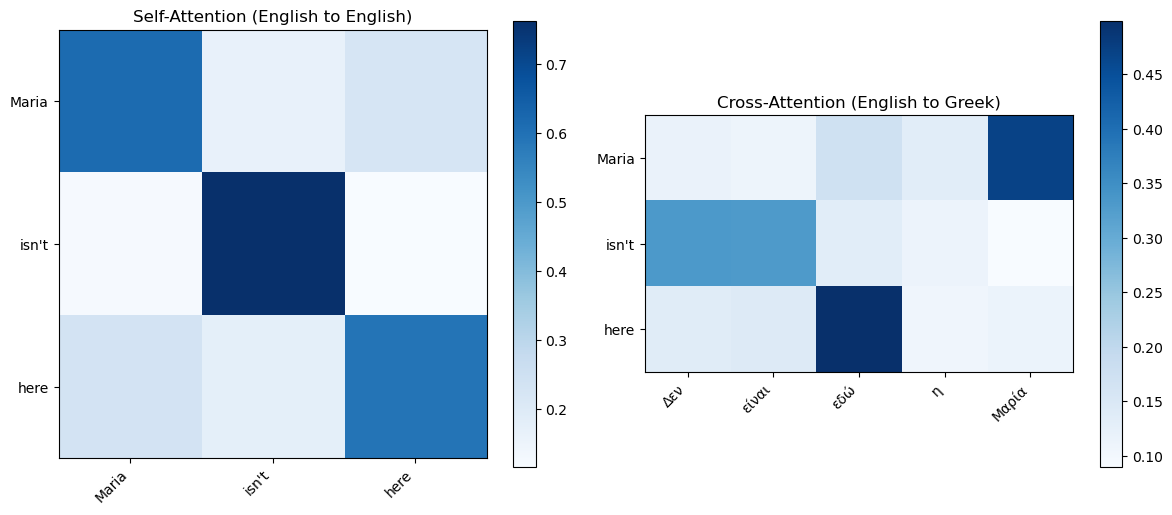

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Define our words to show on the axes of the plots
eng_tokens = ["Maria", "isn't", "here"]
el_tokens = ["Δεν", "είναι", "εδώ", "η", "Μαρία"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Self-Attention ---
im1 = axes[0].imshow(A_self, cmap='Blues')
axes[0].set_title("Self-Attention (English to English)")

# Both axes have the same tokens (English) since it's self-attention
axes[0].set_xticks(np.arange(len(eng_tokens)))
axes[0].set_yticks(np.arange(len(eng_tokens)))
axes[0].set_xticklabels(eng_tokens)
axes[0].set_yticklabels(eng_tokens)

plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
fig.colorbar(im1, ax=axes[0]) # Add color bar

# --- Plot 2: Cross-Attention ---
im2 = axes[1].imshow(A_cross, cmap='Blues')
axes[1].set_title("Cross-Attention (English to Greek)")

# Target (English) is on the Y-axis, Source (Greek) is on the X-axis
axes[1].set_xticks(np.arange(len(el_tokens)))
axes[1].set_yticks(np.arange(len(eng_tokens)))
axes[1].set_xticklabels(el_tokens)
axes[1].set_yticklabels(eng_tokens)

plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
fig.colorbar(im2, ax=axes[1])

# Show the final plots
plt.tight_layout()
plt.show()

Based on the generated heatmaps above, we can observe some distinct differences between the two mechanisms:

**Self-Attention (English to English)**: The resulting $3 \times 3$ matrix shows strong attention weights/scores along the diagonal. This indicates that each token/word is primary focused on itself, while paying minimal attention to the other words in this sentence.

**Cross-Attention (English to Greek)**: The $3 \times 5$ matrix clearly illustrates that the English word/token "Maria" strongly cooresponds to the Greek key "Μαρία", and "here" to "εδώ". Most notably, the English token "isn't" gives almost the same attention score to the Greek tokens "Δεν" and "είναι". 

#### Question 5

Η διακύμανση του εσωτερικού γινομένου: Όταν υπολογίζουμε το εσωτερικό γινόμενο $q_i \cdot k_j$, ουσιαστικά προσθέτουμε $d_k$ όρους. Κάθε όρος είναι το γινόμενο δύο ανεξάρτητων τυχαίων μεταβλητών, από τα ανεξάρτητα τυχαία διανύσματα, με μηδενικό μέσο και διακύμανση $1$. Η διακύμανση του γινομένου δύο τέτοιων μεταβλητών είναι $1 \times 1 = 1$.Επομένως, επειδή προσθέτουμε $d_k$ τέτοιους ανεξάρτητους όρους, η συνολική διακύμανση του εσωτερικού γινομένου αθροίζεται και γίνεται $d_k$.

Τι συμβαίνει στη softmax και γιατί είναι προβληματικό: Καθώς το $d_k$ (η διάσταση) αυξάνεται, η διακύμανση των αποτελεσμάτων του εσωτερικού γινομένου μεγαλώνει πάρα πολύ (π.χ. εμφανίζονται πολύ μεγάλες θετικές ή αρνητικές τιμές). Έτσι λοιπόν, αν περάσουμε αυτές τις ακραίες τιμές στη συνάρτηση softmax, η συνάρτηση. λόγω των εκθετικών όρων που έχει, ουσιατικά θα μας δώσει πάρα πολύ μεγάλες τιμές. Επομένως, η μεγαλύτερη τιμή θα κυριαρχήσει παίρνοντας ουσιαστικά πιθανότητα σχεδόν $1.0$, ενώ όλες οι υπόλοιπες θα μηδενιστούν.
Αυτό είναι προβληματικό διότι σε αυτές τις ακραίες περιοχές της softmax, οι κλίσεις (gradients) γίνονται σχεδόν μηδενικές. 'Ετσι λοιπόν ουστικά χωρίς κλίσεις, ο αλγόριθμος backpropagation δεν λειτουργεί και το νευρωνικό δίκτυο σταματά να μαθαίνει.

Πώς επιλύει το πρόβλημα η κλιμάκωση: Διαιρώντας το εσωτερικό γινόμενο με το $\sqrt{d_k}$, πρακτικά διαιρούμε την διακύμανση με το τετράγωνο αυτού του αριθμού (δηλαδή διαιρούμε τη διακύμανση με το $d_k$). Έτσι, η νέα διακύμανση γίνεται σταθερά, ίση με $1$. Οι τιμές διατηρούνται σε ένα φυσιολογικό εύρος ανεξάρτητα από το μέγεθος του μοντέλου, η softmax παραμένει "ομαλή", και οι κλίσεις περνάνε κανονικά κατά την εκπαίδευση.

# Section 3

In [7]:
import torch
import torch.nn as nn
# Hyperparameters
d_model = 64
n_heads = 4 # d_k = d_v = d_model // n_heads = 16

d_ff = 128 # hidden layer of MLP
n_layers = 2 # number of Transformer layers
vocab_size = 1000
max_seq_len = 32
n_classes = 10
class SmallTransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
        d_model=d_model,
        nhead=n_heads,
        dim_feedforward=d_ff,
        batch_first=True,
        norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer,
        num_layers=n_layers)
        self.fc_out = nn.Linear(d_model, n_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device)
        h = self.token_emb(x) + self.pos_emb(positions)
        h = self.encoder(h)
        return self.fc_out(h[:, 0, :])
model = SmallTransformerEncoder()
# Print parameter names and shapes
for name, param in model.named_parameters():
    print(f"{name:<55} {str(tuple(param.shape)):>20} "
f"numel={param.numel()}")
print(f"\nNumber of parameters: "
f"{sum(p.numel() for p in model.parameters())}")

token_emb.weight                                                  (1000, 64) numel=64000
pos_emb.weight                                                      (32, 64) numel=2048
encoder.layers.0.self_attn.in_proj_weight                          (192, 64) numel=12288
encoder.layers.0.self_attn.in_proj_bias                               (192,) numel=192
encoder.layers.0.self_attn.out_proj.weight                          (64, 64) numel=4096
encoder.layers.0.self_attn.out_proj.bias                               (64,) numel=64
encoder.layers.0.linear1.weight                                    (128, 64) numel=8192
encoder.layers.0.linear1.bias                                         (128,) numel=128
encoder.layers.0.linear2.weight                                    (64, 128) numel=8192
encoder.layers.0.linear2.bias                                          (64,) numel=64
encoder.layers.0.norm1.weight                                          (64,) numel=64
encoder.layers.0.norm1.bias           

**Question 1 - Model Parameters Analysis**

Βάσει του κώδικα, οι βασικές σταθερές του δικτύου είναι: 
$vocab\_size = 1000$, $d_{model} = 64$, $max\_seq\_len = 32$, $d_{ff} = 128$, και $n_{classes} = 10$. 

Η ανάλυση των παραμέτρων της μοντέλου είναι η ακόλουθη:

### 1. Επίπεδα Ενσωμάτωσης (Embeddings Layers)

* **token_emb.weight** 
  * **Διάσταση:** `(1000, 64)` $\rightarrow$ Προκύπτει από `(vocab_size, d_model)`.
  * **Ρόλος:** Είναι ο πίνακας ενσωμάτωσης των λέξεων του μοντέλου (Word Embeddings). Αντιστοιχίζει το ακέραιο ID κάθε λέξης του λεξιλογίου σε ένα διάνυσμα 64 διαστάσεων όπου η κάθε διάσταση αντιστοιχεί και σε κάποια έννοια-σημασία.
* **pos_emb.weight**
  * **Διάσταση:** `(32, 64)` $\rightarrow$ Προκύπτει από `(max_seq_len, d_model)`.
  * **Ρόλος:** Πίνακας ενσωμάτωσης θέσης (Positional Embeddings). Αντιστοιχίζει την απόλυτη θέση ενός token μέσα στην ακολουθία (από 0 έως 31) σε ένα διάνυσμα 64 διαστάσεων, δίνοντας έτσι στο μοντέλο την πληροφορία για την σειρά των λέξεων.

---

### 2. Πρώτο Επίπεδο Μετασχηματιστή (`encoder.layers.0`)

* **encoder.layers.0.self_attn.in_proj_weight**
  * **Διάσταση:** `(192, 64)` $\rightarrow$ Προκύπτει από `(3 * d_model, d_model)`.
  * **Ρόλος:** Ενιαίος πίνακας γραμμικής προβολής για τη δημιουργία των $Q, K, V$. Αντί για 3 ξεχωριστούς πίνακες διαστάσεων $64 \times 64$ ο καθένας, το PyTorch τους εννοποιεί σε έναν.
* **encoder.layers.0.self_attn.in_proj_bias**
  * **Διάσταση:** `(192,)` $\rightarrow$ Προκύπτει από `(3 * d_model,)`.
  * **Ρόλος:** Τα διανύσματα μεροληψίας (biases) που προστίθενται στον υπολογισμό των $Q, K, V$.
* **encoder.layers.0.self_attn.out_proj.weight**
  * **Διάσταση:** `(64, 64)` $\rightarrow$ Προκύπτει από `(d_model, d_model)`.
  * **Ρόλος:** Πίνακας γραμμικής προβολής της εξόδου του μηχανισμού Multi-Head Attention. Συνδυάζει την πληροφορία από όλα τα Heads.
* **encoder.layers.0.self_attn.out_proj.bias**
  * **Διάσταση:** `(64,)` $\rightarrow$ Προκύπτει από `(d_model,)`.
  * **Ρόλος:** Είναι η μεροληψία (bias) για την τελική προβολή του μηχανισμού προσοχής.
* **encoder.layers.0.linear1.weight**
  * **Διάσταση:** `(128, 64)` $\rightarrow$ Προκύπτει από `(d_ff, d_model)`.
  * **Ρόλος:** Πίνακας βαρών του 1ου κρυφού επιπέδου του Feed-Forward Network (MLP). Προβάλλει την αναπαράσταση από τις 64 στις 128 διαστάσεις.
* **encoder.layers.0.linear1.bias**
  * **Διάσταση:** `(128,)` $\rightarrow$ Προκύπτει από `(d_ff,)`.
  * **Ρόλος:** Η μεροληψία του 1ου επιπέδου του Feed-Forward Network.
* **encoder.layers.0.linear2.weight**
  * **Διάσταση:** `(64, 128)` $\rightarrow$ Προκύπτει από `(d_model, d_ff)`.
  * **Ρόλος:** Πίνακας βαρών του 2ου επιπέδου του Feed-Forward Network. Ουσιαστικά επαναφέρει την πληροφορία από τις 128 διαστάσεις πίσω στις αρχικές 64.
* **encoder.layers.0.linear2.bias**
  * **Διάσταση:** `(64,)` $\rightarrow$ Προκύπτει από `(d_model,)`.
  * **Ρόλος:** Η μεροληψία του 2ου επιπέδου του Feed-Forward Network.
* **encoder.layers.0.norm1.weight** & **norm1.bias**
  * **Διάσταση:** `(64,)` και `(64,)` $\rightarrow$ Προκύπτουν από `(d_model,)`.
  * **Ρόλος:** Οι εκπαιδεύσιμες παράμετροι κλιμάκωσης $\gamma$ (`weight`) και μετατόπισης $\beta$ (`bias`) του 1ου Layer Normalization (εφαρμόζεται μετά την αυτοπροσοχή).
* **encoder.layers.0.norm2.weight** & **norm2.bias**
  * **Διάσταση:** `(64,)` και `(64,)` $\rightarrow$ Προκύπτουν από `(d_model,)`.
  * **Ρόλος:** Οι αντίστοιχες παράμετροι $\gamma$ και $\beta$ του 2ου Layer Normalization (εφαρμόζεται μετά το Feed-Forward Network).

---

### 3. Δεύτερο Επίπεδο Μετασχηματιστή (`encoder.layers.1`)

* Όλες οι παράμετροι της μορφής **`encoder.layers.1.*`** έχουν **ακριβώς τον ίδιο ρόλο και τον ίδιο τρόπο υπολογισμού διαστάσεων** με τις αντίστοιχες παραμέτρους του `encoder.layers.0`. Αποτελούν το δεύτερο, δομικά ;όμοιο block επεξεργασίας του Transformer (καθώς $n_{layers} = 2$).

---

### 4. Επίπεδο Ταξινόμησης (`fc_out`)

* **fc_out.weight**
  * **Διάσταση:** `(10, 64)` $\rightarrow$ Προκύπτει από `(n_classes, d_model)`.
  * **Ρόλος:** Πίνακας βαρών του τελικού επιπέδου γραμμικής ταξινόμησης. Μετατρέπει το τελικό διάνυσμα των 64 διαστάσεων σε σκορ (logits) για καθεμία από τις 10 πιθανές κλάσεις.
* **`fc_out.bias`**
  * **Διάσταση:** `(10,)` $\rightarrow$ Προκύπτει από `(n_classes,)`.
  * **Ρόλος:** Η τελική μεροληψία (bias) του τελικού γραμμικού ταξινομητή.

#### Question 2


#### Α. Μαθηματική Ισοδυναμία
Η ιδιότητα που εφαρμόζεται είναι η **επιμεριστική ιδιότητα του πολλαπλασιασμού πινάκων** , η οποία αποτελεί άμεση συνέπεια της γραμμικότητας του πολλαπλασιαμού πινάκων, αρκεί να έχουν όλοι τις κατάλληλες διαστάσεις. 

Η μαθηματική διατύπωση αυτής της ιδιότητας την οποία εκμεταλεύεται και το PyTorch για να πραγματοποιεί τους πολλαπλασισμούς πικάνων είναι η ακόλουθη:

$$X \cdot W_{in\_proj}^T = X \cdot \begin{bmatrix} (W^Q)^T & (W^K)^T & (W^V)^T \end{bmatrix} = \begin{bmatrix} X(W^Q)^T & X(W^K)^T & X(W^V)^T \end{bmatrix} = \begin{bmatrix} Q & K & V \end{bmatrix}$$

Έτσι λοιπόν αν πάρουμε το τελικό αποτέλεσμα του πολλαπλασιαμού και το διαχωρίσουμε σε τρία ίσα τμήματα, προκύπτουν ταυτόχρονα οι ζητούμενοι πίνακες $Q, K$ και $V$ που χρησιμοποιούνται για τον υπολογισμό του μηχανισμού προσοχής.

#### Β. Υπολογιστικό Πλεονέκτημα
1. **Μείωση του Overhead:** Στην ουσία η CPU στέλνει εντολή εκτέλεσης στη GPU **μόνο μία φορά** αντί για τρεις.
2. **Βελτιστοποίηση Μνήμης:** Ο πίνακας εισόδου $X$ διαβάζεται από τη μνήμη της GPU **μία φορά** και πολλαπλασιάζεται απευθείας και με τα τρία σετ βαρών.
3. **Υψηλότερος Παραλληλισμός:** Οι πυρήνες της GPU αξιοποιούνται στο 100% όταν πολλαπλασιάζουν έναν μεγάλο πίνακα (εδώ πλάτους 192) παρά τρεις μικρούς (πλάτους 64).